In [1]:
import torch
from torch import nn
import d2l
from cocoloader import cocoloader
from model.ColorAnything import ColorAnything

In [2]:
net = ColorAnything()
net.to('cuda')


Backbone does not define embed_dims, using [embed_dim] * n_blocks=[384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384] instead
Backbone does not define input_pad_size, using patch_size=16 instead
c:\ProgramData\miniconda3\envs\rgb\lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


ColorAnything(
  (model): Sequential(
    (0): EncoderDecoder(
      (encoder): DinoVisionTransformerWrapper(
        (backbone): DinoVisionTransformer(
          (patch_embed): PatchEmbed(
            (proj): Conv2d(1, 384, kernel_size=(16, 16), stride=(16, 16))
            (norm): Identity()
          )
          (rope_embed): RopePositionEmbedding()
          (blocks): ModuleList(
            (0-11): 12 x SelfAttentionBlock(
              (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
              (attn): SelfAttention(
                (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
                (attn_drop): Dropout(p=0.0, inplace=False)
                (proj): Linear(in_features=384, out_features=384, bias=True)
                (proj_drop): Dropout(p=0.0, inplace=False)
              )
              (ls1): LayerScale()
              (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
              (mlp): Mlp(
                (f

loss 0.043, train absrel_score 0.840, test absrel_score 0.841
19.7 examples/sec on [device(type='cuda', index=0)]


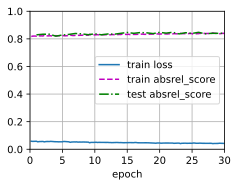

In [10]:
train_iter = cocoloader(r'E:\work\Code\ColorAnything\data\train_small', batch_size=4)
test_iter = cocoloader(r'E:\work\Code\ColorAnything\data\test_small', batch_size=4)
start_epoch = 20
num_epochs = 30
lr = 5e-5

net.load_state_dict(torch.load(f'checkpoints/{start_epoch}.pth'))
trainer = torch.optim.AdamW(net.parameters(), lr=lr)
d2l.train_ch13(net, train_iter, test_iter, nn.MSELoss(), trainer, num_epochs)
torch.save(net.state_dict(), f'checkpoints/{start_epoch + num_epochs}.pth')

True

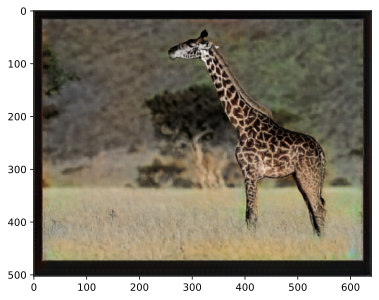

In [ ]:
import cv2
from matplotlib import pyplot as plt
raw_img = cv2.imread(r'E:\work\Code\ColorAnything\examples\000000581767.jpg')
pred = net.infer_image(raw_img, input_size=1036)
plt.imshow(pred) 
pred_bgr = cv2.cvtColor(pred, cv2.COLOR_RGB2BGR)
filename = '\\000000581767.jpg'
cv2.imwrite(r'E:\work\Code\ColorAnything\example_output' + filename, pred_bgr)